<hr size=5 color='#002883'>

<p align="center"> <font size=7 color='#002883'> Meteorologia Sinótica III (2025)

<p align="left"> <font size=5 color='#002883'> Professores:  

* Prof. Dr. Pedro Leite da Silva Dias
* Prof. Dr. Ricardo Hallak


<p align="left"> <font size=5 color='#002883'> Monitor:

* Ronald Guiuseppi Ramírez Nina [PhD. Candidate in Atmospheric Sciences]
* email: ronald.ramirez.nina@alumni.usp.br

<hr size=5 color='#002883'>

<hr size=5 color='#002883'>

**<p align="center"> <font size=8 color='#002883'> Elaboração de diagramas de Hovmoller dos termos do balanço de vorticidade, calor e umidade**

<hr size=5 color='#002883'>

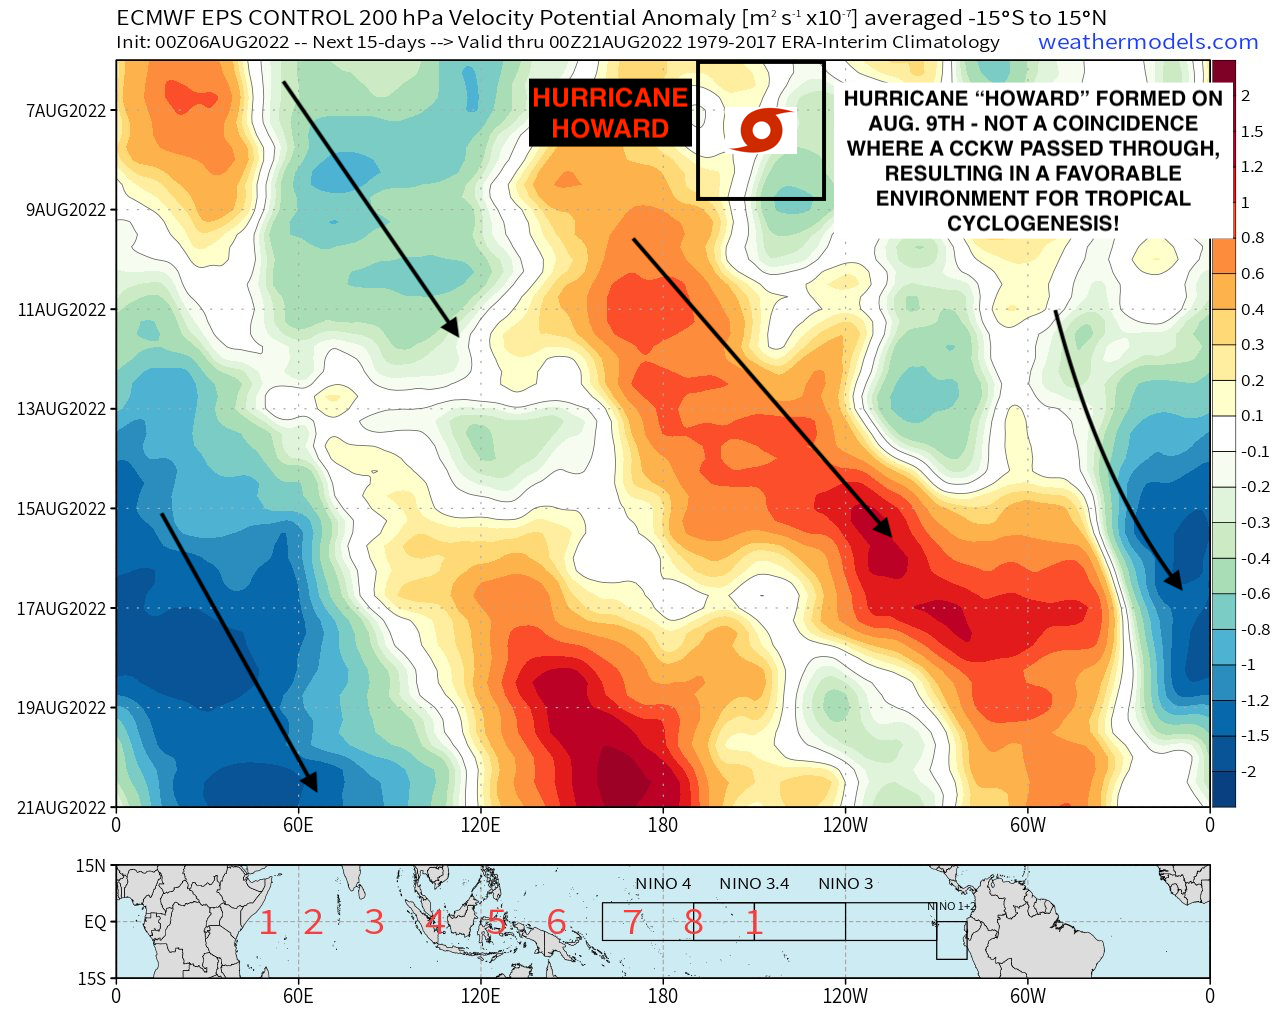

Figura Extraída de:
- https://blog.weather.us/velocity-potential-subseasonal-forecasting-using-a-hovmoller-diagram/

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **1. preparação do Colab** <font>

<font size=4 color='#002883'> Executar as duas células de abaixo: <font>

In [1]:
# @title #### <font color='#002883'> Instalar livrarias <font>
%%capture
!pip install cartopy
!pip install cmocean
!pip install xarray dask netCDF4 bottleneck pydap

<font size=4 color='#002883'> **2. Importar livrarias e montar o drive** <font>

In [2]:
# @title #### <font color='#002883'> Importar librarias  numpy, pandas, xarray, e outras <font>
%%capture

# Livrarias para ler e processar dados
import xarray as xr
import pandas as pd
import numpy as np

# Livrarias para gerar gráficos
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cmocean as cmo
import os

# Importar o drive
from google.colab import drive
drive.mount('/content/drive')

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **3. Acessar aos resultados dos termos do Balanço de Calor do evento de ciclone entre 05-12-2025 até o dia 15-12-2025** <font>

In [3]:
# @title ## <font color='#002883'> Configurtações gerais para o balanço de calor<font>
%%capture

# =====================================================
# Configurações gerais
# =====================================================

budget = 'heat'
variables = ['AdvHTemp', 'AdvVTemp', 'Omega', 'ResT', 'Sigma', 'dTdt']
# Definir fases
fases = [
    ("Incipiente", "2025-12-05 00:00", "2025-12-08 12:00", "lightblue"),
    ("Intensificação", "2025-12-08 12:00", "2025-12-10 18:00", "orange"),
    ("Madura", "2025-12-10 18:00", "2025-12-13 06:00", "red"),
    ("Desintensificação", "2025-12-13 06:00", "2025-12-15 18:00", "green"),
]

<font size=4 color='#002883'> **4. Configurar DataFrame para fazer o plot dos termos do balanço de calor** <font>


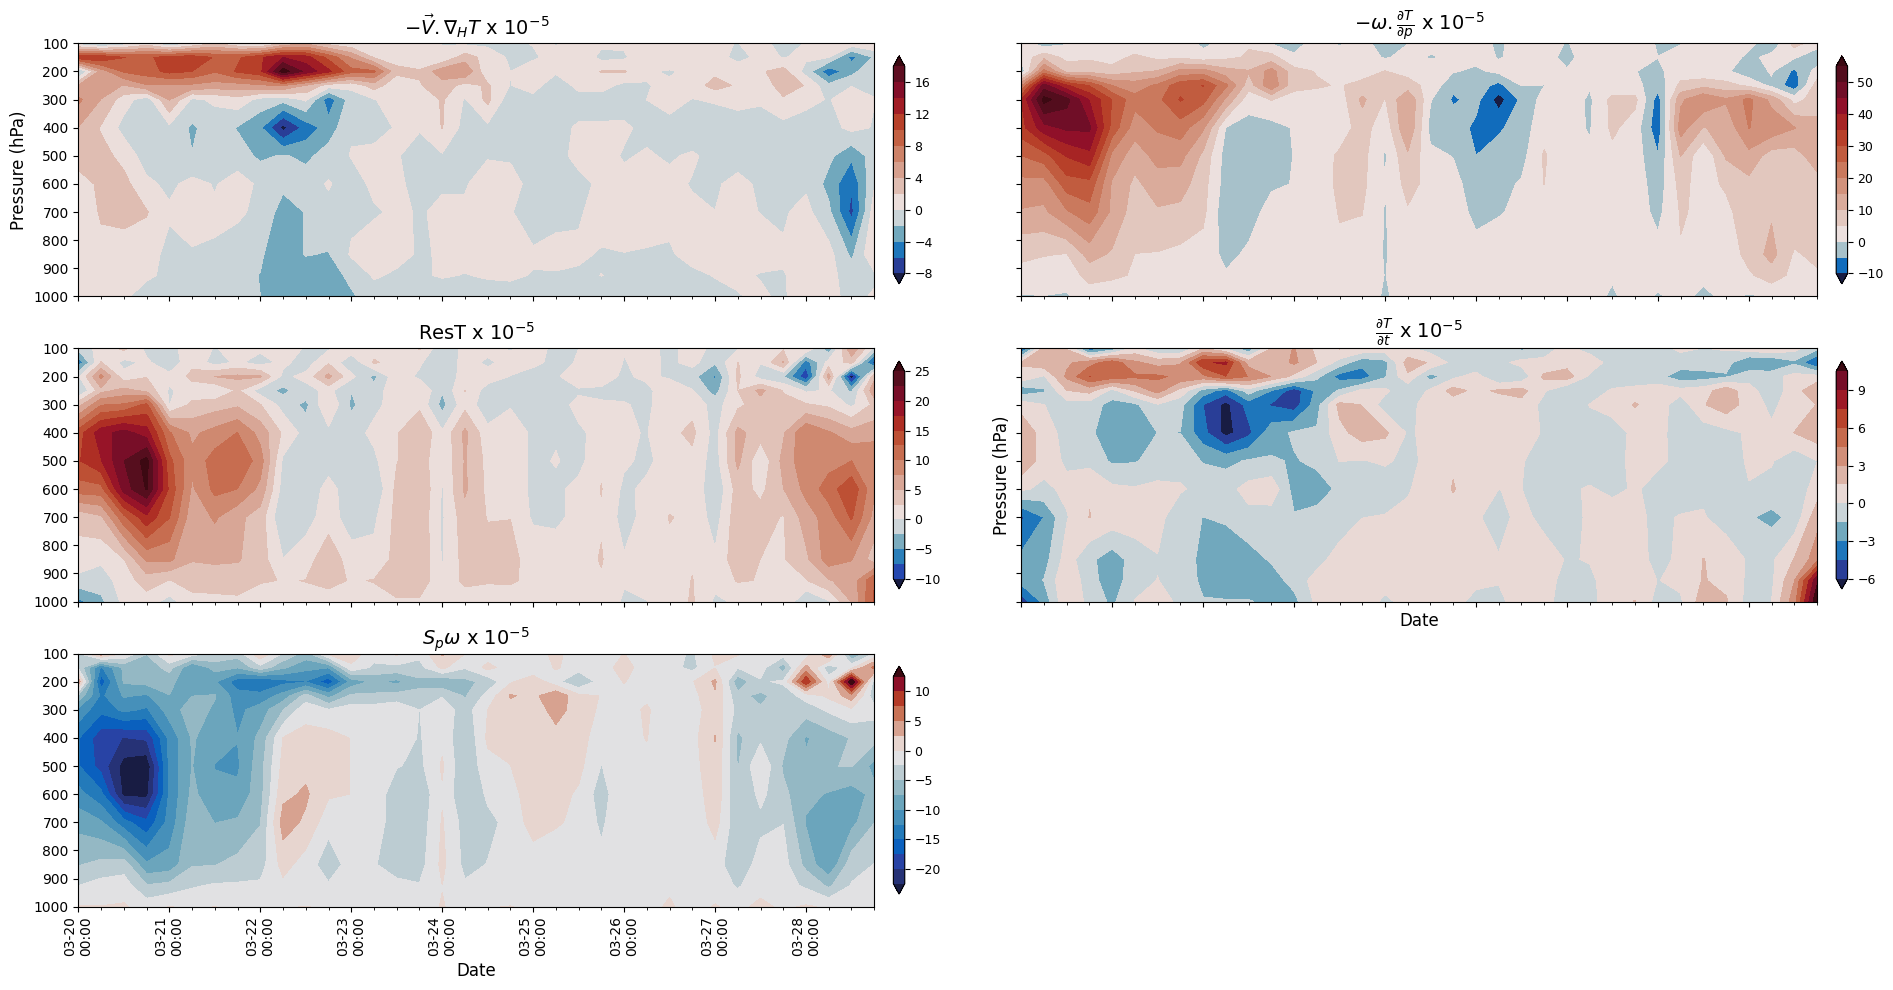

In [4]:
# @title ## <font color='#002883'> Ler .csv files do balanço de calor e fazer o plot considerando o Sp x Sigma<font>

import os
import pandas as pd
import matplotlib.colors as colors
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

# ==========================================================
# Lista de variáveis a plotar
# Troque Omega e Sigma por SpOmega
# ==========================================================
variables_plot = ['AdvHTemp', 'AdvVTemp', 'ResT', 'dTdt', 'SpOmega']
titles_plot = [r'$-\vec{V}.\nabla_H T$', r'$-\omega.\frac{\partial T}{\partial p}$', 'ResT', r'$\frac{\partial T}{\partial t}$', 'SpOmega']
# 'AdvHTemp'

# ajuste os nomes conforme os arquivos reais que você usa

# ==========================================================
# Criar figura com 2 linhas x 3 colunas
# ==========================================================
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

# ==========================================================
# Loop sobre as variáveis
# ==========================================================
for ax, variable, titles in zip(axes, variables_plot, titles_plot):

    # Caminho da pasta com os resultados do ATMOSBUD
    path_drive = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-III-2026/Aula3_ATMOSBUD_Reanalysis_track_files/equipe4_catarina_track'
    base_path = f'{path_drive}/{budget}_terms'

    # ======================================================
    # Caso especial: produto Sigma * Omega
    # ======================================================
    if variable == 'SpOmega':
        file_omega = os.path.join(base_path, 'Omega.csv')
        file_sigma = os.path.join(base_path, 'Sigma.csv')

        df_omega = pd.read_csv(file_omega, index_col=0)
        df_sigma = pd.read_csv(file_sigma, index_col=0)

        # Converter colunas para datetime
        df_omega.columns = pd.to_datetime(df_omega.columns)
        df_sigma.columns = pd.to_datetime(df_sigma.columns)

        # Converter índice de Pa para hPa
        df_omega.index = pd.to_numeric(df_omega.index, errors='coerce') / 100
        df_sigma.index = pd.to_numeric(df_sigma.index, errors='coerce') / 100

        # Garantir dados numéricos
        df_omega = df_omega.apply(pd.to_numeric, errors='coerce')
        df_sigma = df_sigma.apply(pd.to_numeric, errors='coerce')

        # Alinhar índices e colunas
        common_index = df_omega.index.intersection(df_sigma.index)
        common_columns = df_omega.columns.intersection(df_sigma.columns)

        df_omega = df_omega.loc[common_index, common_columns]
        df_sigma = df_sigma.loc[common_index, common_columns]

        # Produto
        df = df_sigma * df_omega * 1e5
        title_plot = r'$S_p\omega$ x $10^{-5}$'

    # ======================================================
    # Caso normal: ler um arquivo CSV
    # ======================================================
    else:
        path_file = os.path.join(base_path, f'{variable}.csv')

        df = pd.read_csv(path_file, index_col=0)
        df.columns = pd.to_datetime(df.columns)
        df.index = pd.to_numeric(df.index, errors='coerce') / 100
        df = df.apply(pd.to_numeric, errors='coerce') * 1e5

        title_plot = titles + ' x $10^{-5}$'

    # ======================================================
    # Configurar barra de cores
    # ======================================================
    vmin = df.to_numpy().min()
    vmax = df.to_numpy().max()

    if vmin < 0 and vmax > 0:
        norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = None

    # ======================================================
    # Plot
    # ======================================================
    im = ax.contourf(
        df.columns,
        df.index,
        df.values,
        cmap=cmo.cm.balance,
        levels=15,
        norm=norm,
        extend='both'
    )

    # Inverter eixo y
    ax.set_ylim(df.index.max(), df.index.min())

    # Título
    ax.set_title(title_plot, fontsize=14)

    # Linhas verticais das fases
    #for _, inicio, fim, _ in fases:
    #    ax.axvline(pd.to_datetime(inicio), color='yellow', linestyle='--', linewidth=1.5)
    #    ax.axvline(pd.to_datetime(fim), color='yellow', linestyle='--', linewidth=1.5)

    # Colorbar individual
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=9)

# ==========================================================
# Formatação dos eixos
# ==========================================================
for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%m-%d\n%H:%M'))
    ax.tick_params(axis='x', labelrotation=90)
    ax.tick_params(axis='both', labelsize=10)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))

# Labels apenas na borda externa
for ax in axes[3:]:
    ax.set_xlabel('Date', fontsize=12)

for ax in [axes[0], axes[3]]:
    ax.set_ylabel('Pressure (hPa)', fontsize=12)

# Apagar o último painel sem dados
for j in range(len(variables_plot), len(axes)):
    fig.delaxes(axes[j])
# ==========================================================
# Ajuste final
# ==========================================================
plt.tight_layout()

path_out = path_drive + '/ciclone_track'
out_dir = os.path.join(path_out, 'Figuras_Hovmoller_Balance')
os.makedirs(out_dir, exist_ok=True)

plt.savefig(
    os.path.join(out_dir, f'hovmoller_6terms_{budget}.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **5. Acessar aos resultados dos termos do Balanço de Vorticidade do evento de ciclone entre 05-12-2025 até o dia 15-12-2025** <font>

In [5]:
# @title ## <font color='#002883'> Configurações gerais para o balanço de vorticidade<font>
%%capture

# =====================================================
# Configurações gerais
# =====================================================

budget = 'vorticity'
variables = ['AdvHZeta', 'AdvVZeta', 'ResZ',
             'Tilting', 'Zeta', 'ZetaDivH',
             'dZdt', 'fDivH', 'vxBeta']
titles_plot = [r'$-\vec{V}.\nabla_H \zeta$', r'$-\omega.\frac{\partial \zeta}{\partial p}$', r'Res $\zeta$',
             r'$(\frac{\partial \zeta}{\partial y} \frac{\partial u}{\partial p} - \frac{\partial \zeta}{\partial x} \frac{\partial v}{\partial p})$',
               r'$\zeta$', r'$-\zeta.\nabla_H \vec{V}$',
             r'$\frac{\partial \zeta}{\partial t}$', r'$-f.\nabla_H \vec{V}$', r'$-v.\beta$']

# Definir fases
fases = [
    ("Incipiente", "2025-12-05 00:00", "2025-12-08 12:00", "lightblue"),
    ("Intensificação", "2025-12-08 12:00", "2025-12-10 18:00", "orange"),
    ("Madura", "2025-12-10 18:00", "2025-12-13 06:00", "red"),
    ("Desintensificação", "2025-12-13 06:00", "2025-12-15 18:00", "green"),
]

<font size=4 color='#002883'> **6. Configurar DataFrame para fazer o plot dos termos do balanço de vorticidade** <font>

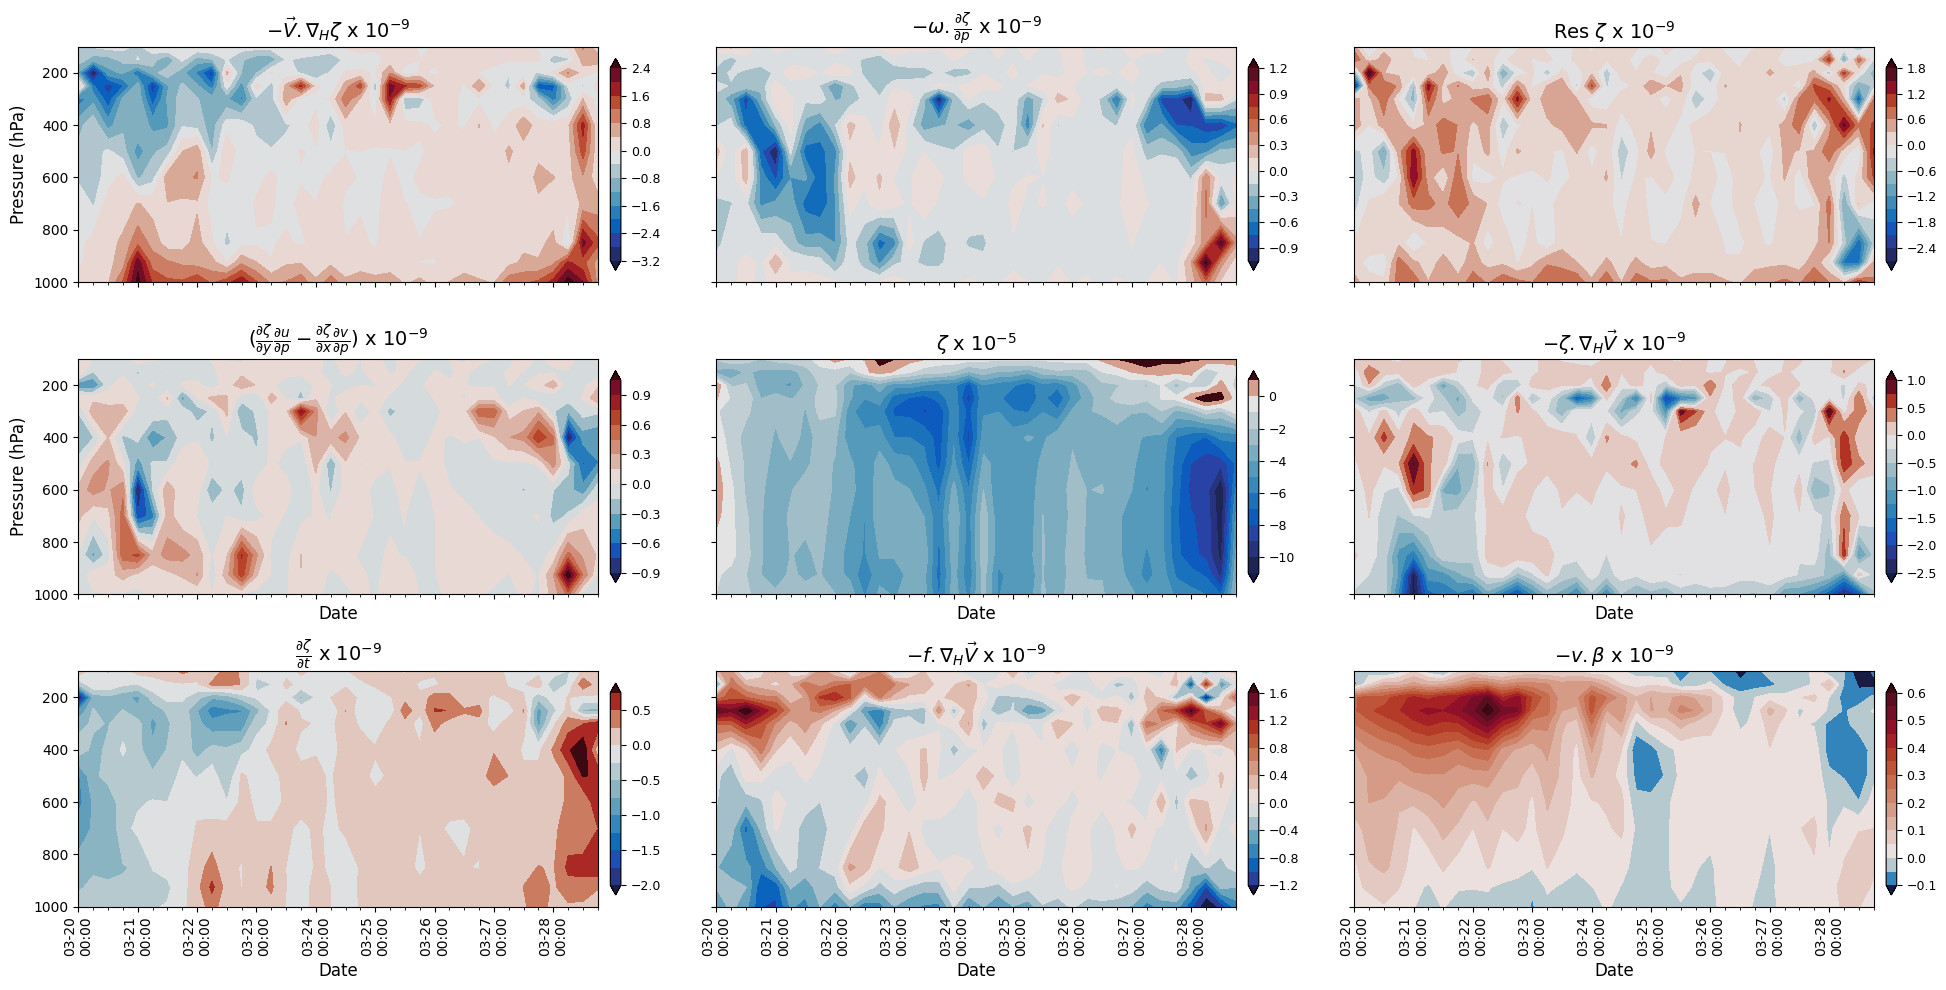

In [6]:
# @title ## <font color='#002883'> Ler .csv files do balanço de vorticidade e fazer o plot<font>

# ==========================================================
# Criar figura com 2 linhas x 3 colunas
# ==========================================================
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

# ==========================================================
# Loop sobre as variáveis
# ==========================================================
for ax, variable, titles in zip(axes, variables, titles_plot):

    # Caminho do arquivo
    # Caminho da pasta com os resultados do ATMOSBUD no meu drive (MODIFICAR PARA SEU CASO)
    path_drive = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-III-2026/Aula3_ATMOSBUD_Reanalysis_track_files/equipe4_catarina_track'
    base_path = f'{path_drive}/{budget}_terms'

    # Ler CSV
    path_file = os.path.join(base_path, f'{variable}.csv')
    df = pd.read_csv(path_file, index_col=0)

    # Converter colunas para datetime
    df.columns = pd.to_datetime(df.columns)
    # Converter índice de Pa para hPa
    df.index = df.index.astype(int) / 100
    # Garantir que os dados são numéricos
    if variable == 'Zeta':
      df = df.apply(pd.to_numeric, errors='coerce') * 1e5
    else:
      df = df.apply(pd.to_numeric, errors='coerce') * 1e9

    # Configurando os valores da barra de cores
    vmin = df.to_numpy().min()
    vmax = df.to_numpy().max()
    if vmin < 0 and vmax > 0:
        norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = None

    # Plot
    im = ax.contourf(
        df.columns,
        df.index,
        df.values,
        cmap=cmo.cm.balance,
        levels=15,
        norm=norm,
        extend='both'
    )

    # Inverter eixo y
    #ax.invert_yaxis()
    ax.set_ylim(df.index.max(), df.index.min())

    # Título
    if variable == 'Zeta':
      ax.set_title(titles + ' x $10^{-5}$', fontsize=14)
    else:
      ax.set_title(titles + ' x $10^{-9}$', fontsize=14)

    # Linhas verticais das fases
    #for _, inicio, fim, _ in fases:
    #    ax.axvline(pd.to_datetime(inicio), color='yellow', linestyle='--', linewidth=1.5)
    #    ax.axvline(pd.to_datetime(fim), color='yellow', linestyle='--', linewidth=1.5)

    # Colorbar individual
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=9)

# ==========================================================
# Formatação dos eixos
# ==========================================================
for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%m-%d\n%H:%M'))
    ax.tick_params(axis='x', labelrotation=90)
    ax.tick_params(axis='both', labelsize=10)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))

# Labels apenas na borda externa
for ax in axes[3:]:
    ax.set_xlabel('Date', fontsize=12)

for ax in [axes[0], axes[3]]:
    ax.set_ylabel('Pressure (hPa)', fontsize=12)

# ==========================================================
# Ajuste final
# ==========================================================
plt.tight_layout()

path_out = path_drive + '/ciclone_track'
out_dir = os.path.join(path_out, 'Figuras_Hovmoller_Balance')
os.makedirs(out_dir, exist_ok=True)

plt.savefig(out_dir + f'/hovmoller_6terms_{budget}.png', dpi=300, bbox_inches='tight')
plt.show()

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **7. Acessar aos resultados dos termos do Balanço de Umidade do evento de ciclone entre 05-12-2025 até o dia 15-12-2025** <font>

In [7]:
# @title ## <font color='#002883'> Configurações gerais para o balanço de umidade<font>
%%capture

# =====================================================
# Configurações gerais
# =====================================================

budget = 'moisture'
variables = ['WaterBudgetResidual', 'WaterBudgetResidual_integrated', 'dQdt',
             'dQdt_integrated', 'divQ', 'divQ_integrated']
titles_plot = ['WaterBudgetResidual', 'WaterBudgetResidual_integrated', r'$\frac{\partial Q}{\partial t}$',
             r'$\int \frac{\partial Q}{\partial t} dp$', r'$\vec{V} .\nabla Q$', r'$\int \vec{V} . \nabla Q dp$']
# Definir fases
fases = [
    ("Incipiente", "2025-12-05 00:00", "2025-12-08 12:00", "lightblue"),
    ("Intensificação", "2025-12-08 12:00", "2025-12-10 18:00", "orange"),
    ("Madura", "2025-12-10 18:00", "2025-12-13 06:00", "red"),
    ("Desintensificação", "2025-12-13 06:00", "2025-12-15 18:00", "green"),
]

<font size=4 color='#002883'> **8. Configurar DataFrame para fazer o plot dos termos do balanço de umidade** <font>

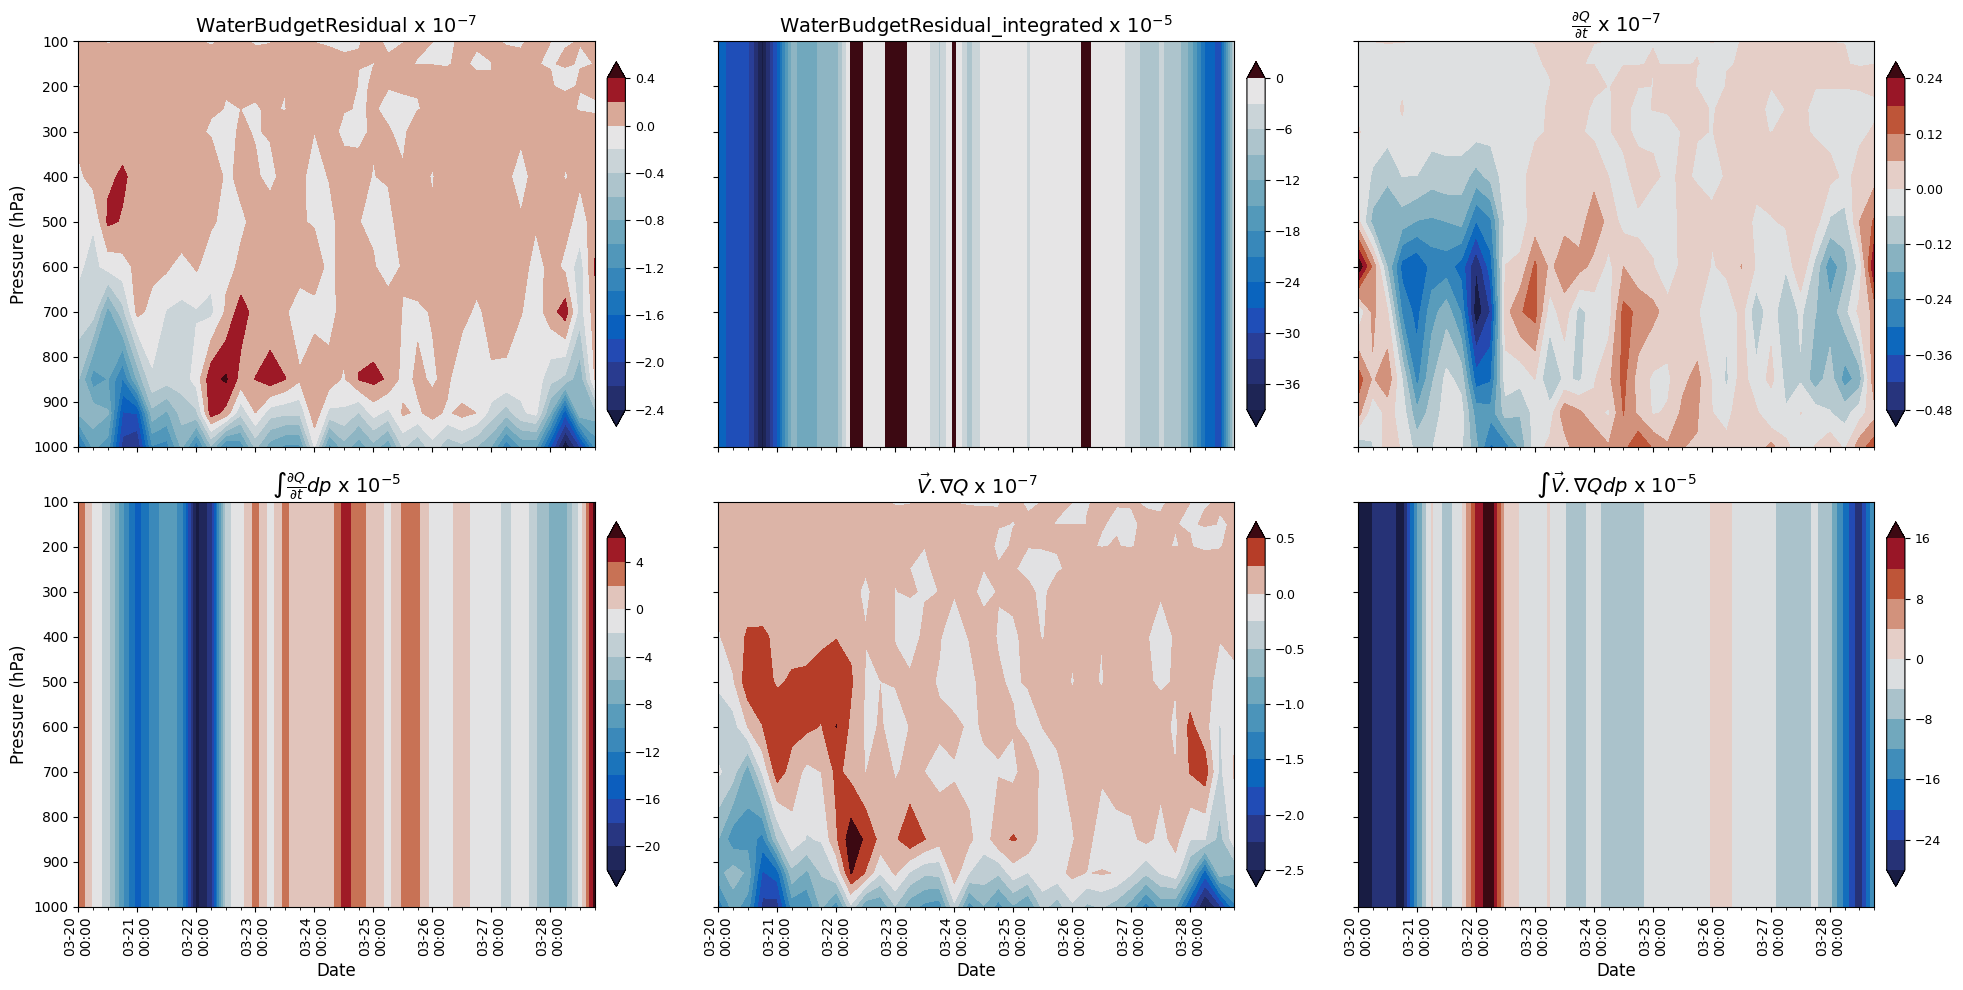

In [8]:
# @title ## <font color='#002883'> Ler .csv files do balanço de umidade e fazer o plot<font>

# ==========================================================
# Criar figura com 2 linhas x 3 colunas
# ==========================================================
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

# ==========================================================
# Loop sobre as variáveis
# ==========================================================
for ax, variable, titles in zip(axes, variables, titles_plot):

    # Caminho do arquivo
    # Caminho da pasta com os resultados do ATMOSBUD no meu drive (MODIFICAR PARA SEU CASO)
    path_drive = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-III-2026/Aula3_ATMOSBUD_Reanalysis_track_files/equipe4_catarina_track'
    path_file = f'/{budget}_terms/{variable}.csv'

    # Ler CSV
    df = pd.read_csv(path_drive + path_file, index_col=0)
    # Converter colunas para datetime
    df.columns = pd.to_datetime(df.columns)
    # Converter índice de Pa para hPa
    df.index = df.index.astype(int) / 100
    # Garantir que os dados são numéricos
    if variable in ['WaterBudgetResidual', 'dQdt', 'divQ']:
      df = df.apply(pd.to_numeric, errors='coerce') * 1e7
      title = titles + ' x $10^{-7}$'
    else:
      df = df.apply(pd.to_numeric, errors='coerce') * 1e5
      title = titles + ' x $10^{-5}$'

    # Configurando os valores da barra de cores
    vmin = df.to_numpy().min()
    vmax = df.to_numpy().max()
    if vmin < 0 and vmax > 0:
        norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = None

    # Plot
    im = ax.contourf(
        df.columns,
        df.index,
        df.values,
        cmap=cmo.cm.balance,
        levels=15,
        norm=norm,
        extend='both'
    )

    # Inverter eixo y
    #ax.invert_yaxis()
    ax.set_ylim(df.index.max(), df.index.min())

    # Título
    ax.set_title(title, fontsize=14)

    # Linhas verticais das fases
    #for _, inicio, fim, _ in fases:
    #    ax.axvline(pd.to_datetime(inicio), color='yellow', linestyle='--', linewidth=1.5)
    #    ax.axvline(pd.to_datetime(fim), color='yellow', linestyle='--', linewidth=1.5)

    # Colorbar individual
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=9)

# ==========================================================
# Formatação dos eixos
# ==========================================================
for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%m-%d\n%H:%M'))
    ax.tick_params(axis='x', labelrotation=90)
    ax.tick_params(axis='both', labelsize=10)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))

# Labels apenas na borda externa
for ax in axes[3:]:
    ax.set_xlabel('Date', fontsize=12)

for ax in [axes[0], axes[3]]:
    ax.set_ylabel('Pressure (hPa)', fontsize=12)

# ==========================================================
# Ajuste final
# ==========================================================
plt.tight_layout()

path_out = path_drive + '/ciclone_track'
out_dir = os.path.join(path_out, 'Figuras_Hovmoller_Balance')
os.makedirs(out_dir, exist_ok=True)

plt.savefig(out_dir + f'/hovmoller_6terms_{budget}.png', dpi=300, bbox_inches='tight')
plt.show()

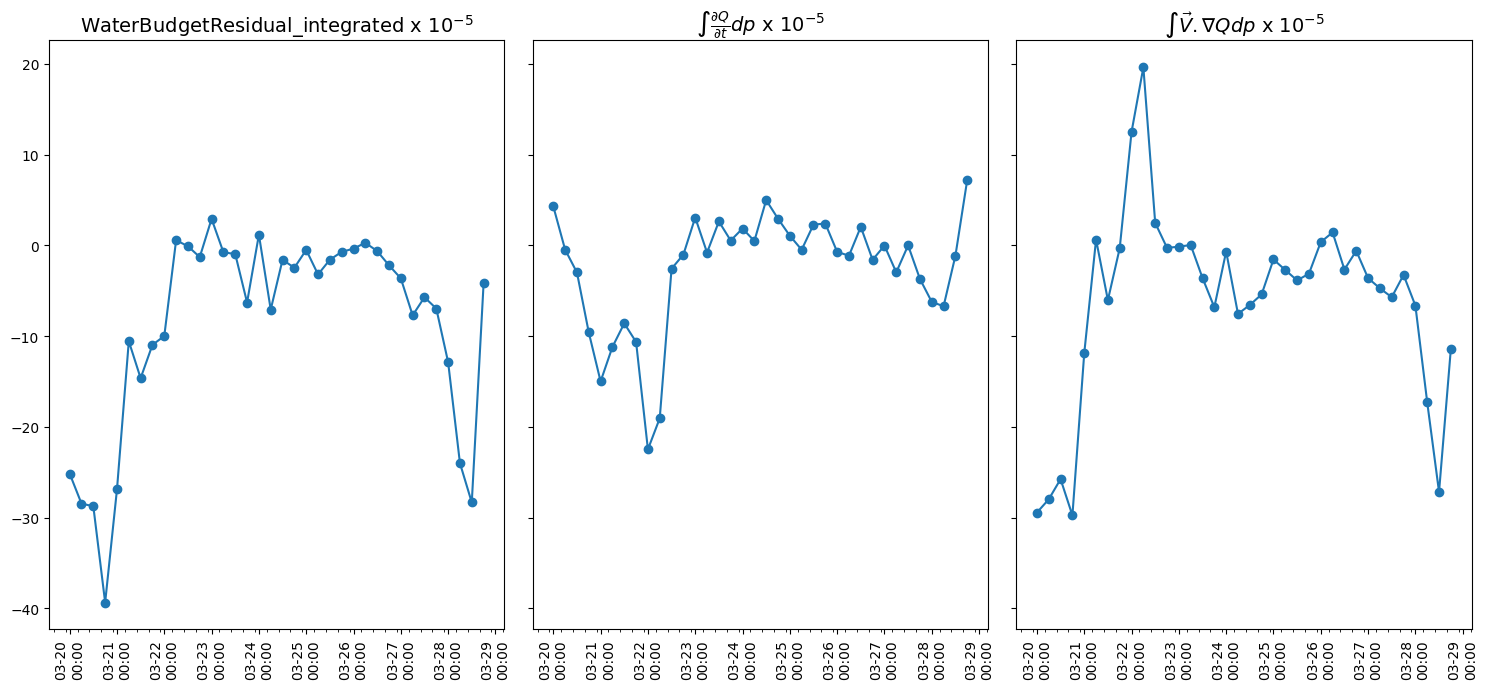

In [9]:
# @title ## <font color='#002883'> Ler .csv files do balanço de umidade e fazer o plot<font>

# ==========================================================
# Criar figura com 2 linhas x 3 colunas
# ==========================================================
budget = 'moisture'
variables = ['WaterBudgetResidual_integrated',
             'dQdt_integrated', 'divQ_integrated']

titles_plot = ['WaterBudgetResidual_integrated',
             r'$\int \frac{\partial Q}{\partial t} dp$', r'$\int \vec{V} . \nabla Q dp$']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 7), sharex=True, sharey=True)
axes = axes.flatten()

# ==========================================================
# Loop sobre as variáveis
# ==========================================================
for ax, variable, titles in zip(axes, variables, titles_plot):

    # Caminho do arquivo
    # Caminho da pasta com os resultados do ATMOSBUD no meu drive (MODIFICAR PARA SEU CASO)
    path_drive = '/content/drive/MyDrive/USP-CURSOS/MONITORIA/METEOROLOGIA-SINOTICA-III-2026/Aula3_ATMOSBUD_Reanalysis_track_files/equipe4_catarina_track'
    path_file = f'/{budget}_terms/{variable}.csv'

    # Ler CSV
    df = pd.read_csv(path_drive + path_file, index_col=0)
    # Converter colunas para datetime
    df.columns = pd.to_datetime(df.columns)
    # Converter índice de Pa para hPa
    df.index = df.index.astype(int) / 100
    # Garantir que os dados são numéricos
    if variable in ['WaterBudgetResidual', 'dQdt', 'divQ']:
      df = df.apply(pd.to_numeric, errors='coerce') * 1e7
      title = titles + ' x $10^{-7}$'
    else:
      df = df.apply(pd.to_numeric, errors='coerce') * 1e5
      title = titles + ' x $10^{-5}$'

    # Configurando os valores da barra de cores
    vmin = df.to_numpy().min()
    vmax = df.to_numpy().max()
    if vmin < 0 and vmax > 0:
        norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    else:
        norm = None

    # Plot
    serie = df.iloc[0]
    ax.plot(serie.index, serie.values, marker='o')

    # Título
    ax.set_title(title, fontsize=14)

# ==========================================================
# Formatação dos eixos
# ==========================================================
for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%m-%d\n%H:%M'))
    ax.tick_params(axis='x', labelrotation=90)
    ax.tick_params(axis='both', labelsize=10)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))

# Labels apenas na borda externa
for ax in axes[3:]:
    ax.set_xlabel('Date', fontsize=12)

#for ax in [axes[0], axes[3]]:
#    ax.set_ylabel('Pressure (hPa)', fontsize=12)

# ==========================================================
# Ajuste final
# ==========================================================
plt.tight_layout()

path_out = path_drive + '/ciclone_track'
out_dir = os.path.join(path_out, 'Figuras_Hovmoller_Balance')
os.makedirs(out_dir, exist_ok=True)

plt.savefig(out_dir + f'/Time_series_{budget}.png', dpi=300, bbox_inches='tight')
plt.show()